# Training Pipeline

In [1]:
# Install this once
!pip install import-ipynb

Classes: ['BACTERIAL_PNEUMONIA', 'NORMAL', 'VIRAL_PNEUMONIA']
Train size: 5216
Validation size: 24
Test size: 625


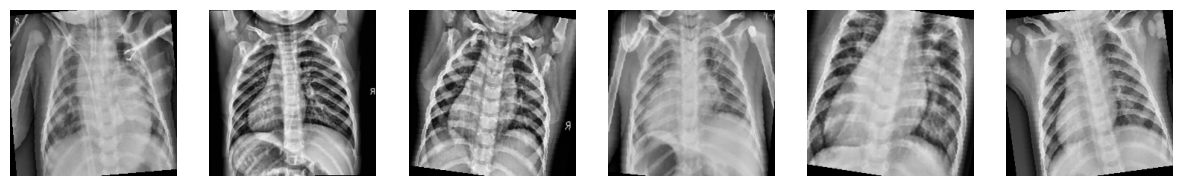

In [2]:
import import_ipynb
import Preprocessing_Pipeline as prep

In [3]:
from torch.utils.data import DataLoader

train_loader = DataLoader(prep.train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(prep.val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(prep.test_dataset, batch_size=32, shuffle=False)

In [4]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cpu


In [5]:
import torch.nn as nn
from torchvision import models

model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Modify final layer for your classes
num_classes = len(prep.train_dataset.classes)

model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)

In [6]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [7]:
import matplotlib.pyplot as plt
from tqdm import tqdm

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

In [8]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), correct / total

In [9]:
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / len(loader), correct / total


Epoch 1/10


100%|██████████| 163/163 [14:00<00:00,  5.16s/it]


Train Loss: 0.5891 | Train Acc: 0.7481
Val   Loss: 1.4340 | Val   Acc: 0.2500

Epoch 2/10


100%|██████████| 163/163 [13:43<00:00,  5.05s/it]


Train Loss: 0.4282 | Train Acc: 0.8161
Val   Loss: 1.4249 | Val   Acc: 0.3333

Epoch 3/10


...

Train Loss: 0.2323 | Train Acc: 0.9057
Val   Loss: 0.6221 | Val   Acc: 0.7500

Epoch 9/10


100%|██████████| 163/163 [13:41<00:00,  5.04s/it]


Train Loss: 0.2030 | Train Acc: 0.9174
Val   Loss: 0.7915 | Val   Acc: 0.7083

Epoch 10/10


100%|██████████| 163/163 [13:43<00:00,  5.05s/it]


Train Loss: 0.1832 | Train Acc: 0.9262
Val   Loss: 0.7873 | Val   Acc: 0.6667


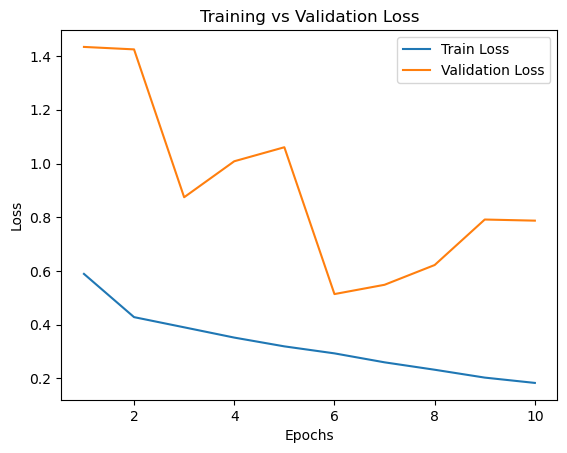

In [10]:
EPOCHS = 10

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    # Store history
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")


# 📊 Plot Loss Curve
plt.figure()
plt.plot(range(1, EPOCHS + 1), train_losses, label="Train Loss")
plt.plot(range(1, EPOCHS + 1), val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [11]:
test_loss, test_acc = evaluate(model, test_loader, criterion)

print("\nTest Results:")
print(f"Loss: {test_loss:.4f}")
print(f"Accuracy: {test_acc:.4f}")


Test Results:
Loss: 0.7121
Accuracy: 0.7888


In [12]:
torch.save(model.state_dict(), "resnet50_pneumonia.pth")

In [13]:
import json
with open("classes.json", "w") as f:
    json.dump(prep.train_dataset.classes, f)